In [1]:
import pandas as pd 
import numpy as np

In [3]:
df = pd.read_csv("credit_card_fraud_10k.csv")

In [4]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB


In [6]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [14]:
df.nunique()

transaction_id         10000
amount                  8788
transaction_hour          24
merchant_category          5
foreign_transaction        2
location_mismatch          2
device_trust_score        75
velocity_last_24h         10
cardholder_age            52
is_fraud                   2
dtype: int64

In [36]:
df["merchant_category"].value_counts()

merchant_category
Food           2093
Clothing       2050
Travel         1990
Grocery        1944
Electronics    1923
Name: count, dtype: int64

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

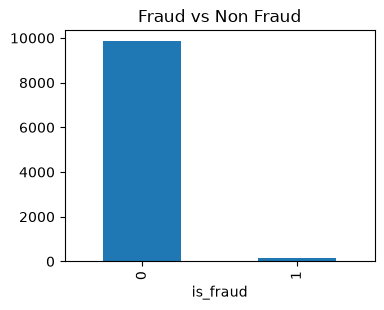

In [23]:
fraud_counts = df["is_fraud"].value_counts()

plt.figure(figsize=(4,3))
fraud_counts.plot(kind='bar')

plt.title("Fraud vs Non Fraud")
plt.show()

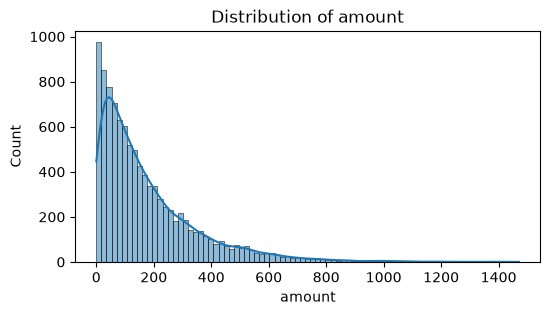

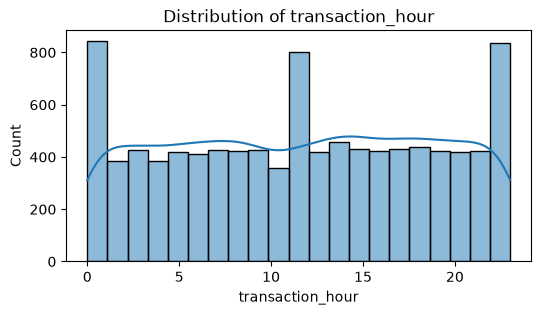

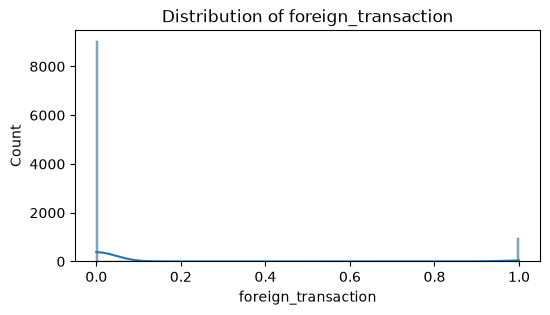

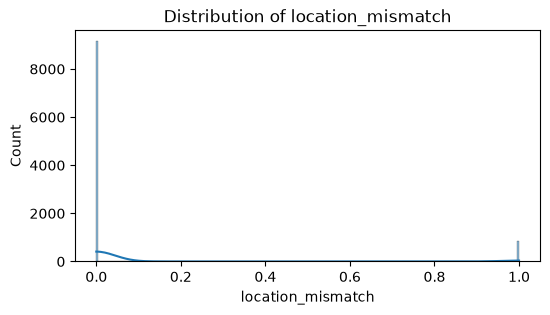

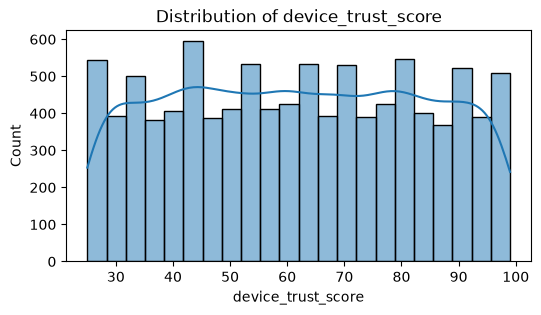

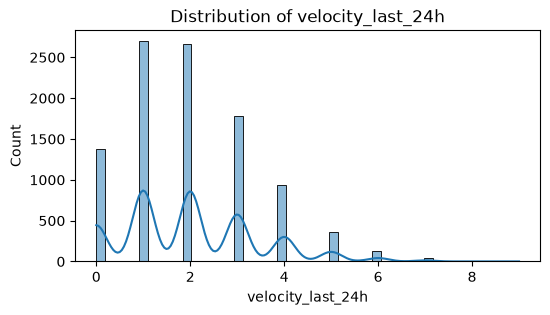

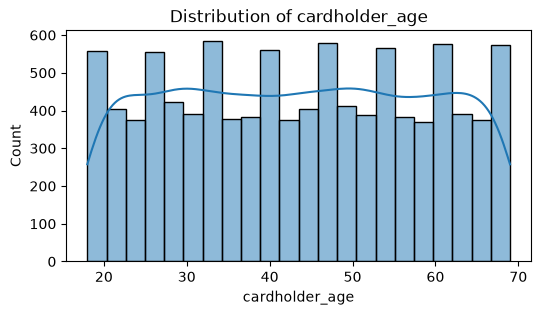

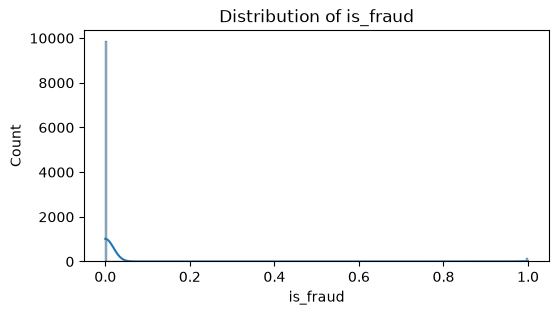

In [25]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    if col != "transaction_id":
        plt.figure(figsize=(6,3))
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

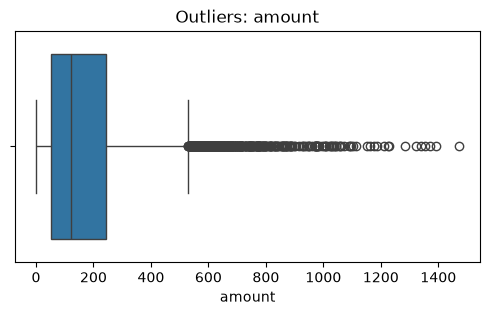

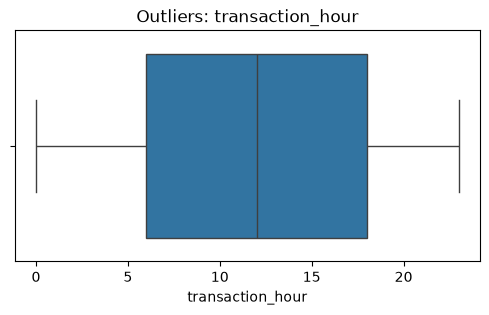

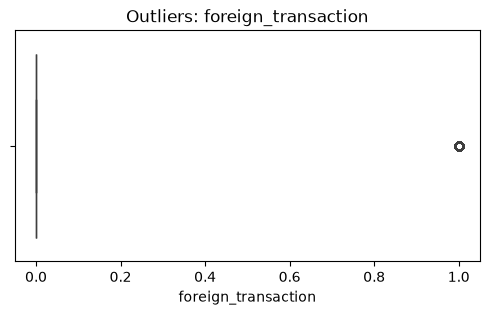

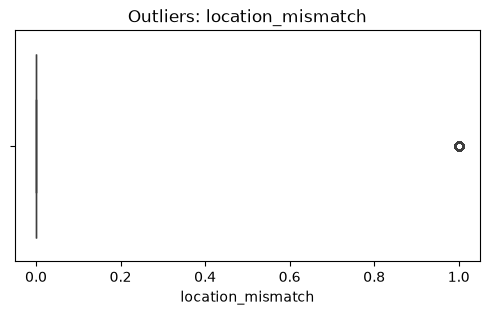

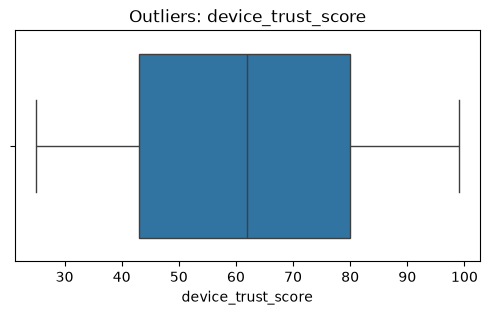

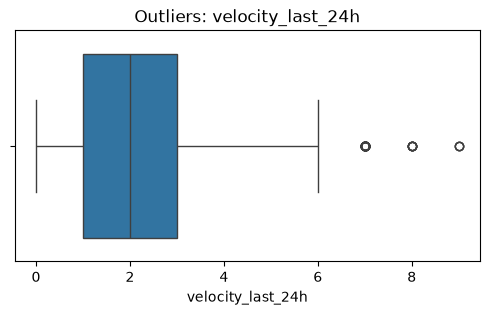

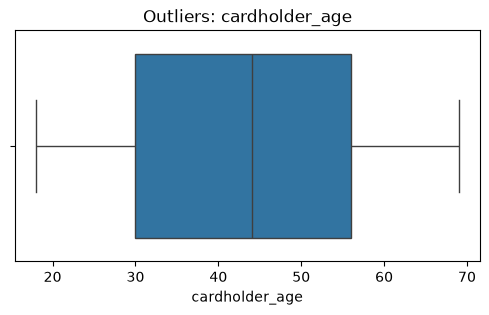

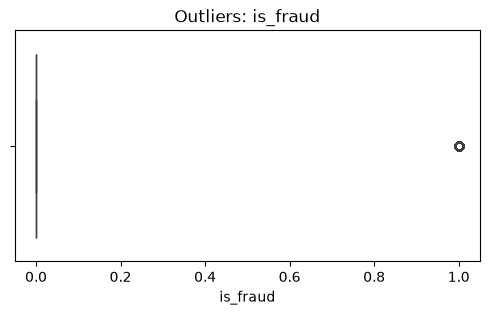

In [27]:
for col in num_cols:
    if col != "transaction_id":
        plt.figure(figsize=(6,3))
        sns.boxplot(x=df[col])
        plt.title(f"Outliers: {col}")
        plt.show()



In [28]:
group_stats = df.groupby("is_fraud").mean(numeric_only=True)
group_stats

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
is_fraud,,,,,,,,
0,5004.129861,175.333015,11.712154,0.090974,0.079704,62.165804,1.990557,43.469794
1,4763.741722,216.182980,3.841060,0.543046,0.476821,37.867550,3.205298,43.397351



Fraud % by foreign_transaction:
 is_fraud                 0     1
foreign_transaction             
0                    99.24  0.76
1                    91.62  8.38


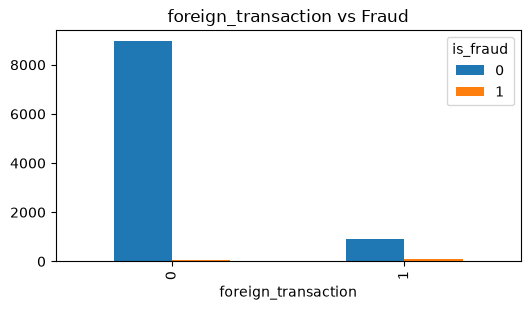


Fraud % by location_mismatch:
 is_fraud               0     1
location_mismatch             
0                  99.14  0.86
1                  91.60  8.40


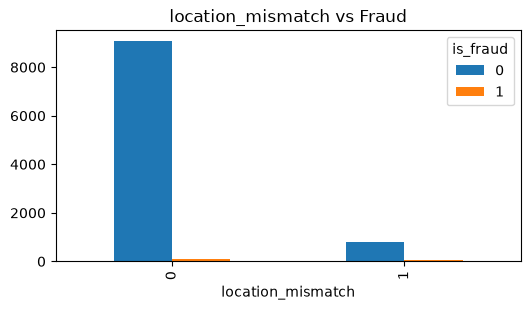

In [29]:
binary_cols = ["foreign_transaction", "location_mismatch"]

for col in binary_cols:
    table = pd.crosstab(df[col], df["is_fraud"], normalize="index") * 100
    print(f"\nFraud % by {col}:\n", table.round(2))

    pd.crosstab(df[col], df["is_fraud"]).plot(kind="bar", figsize=(6,3))
    plt.title(f"{col} vs Fraud")
    plt.show()

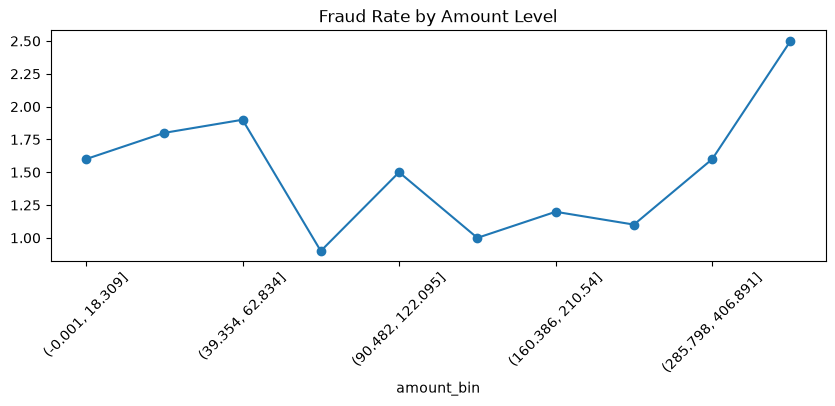

In [30]:
df["amount_bin"] = pd.qcut(df["amount"], q=10)

amount_risk = df.groupby("amount_bin")["is_fraud"].mean() * 100

plt.figure(figsize=(10,3))
amount_risk.plot(marker="o")
plt.title("Fraud Rate by Amount Level")
plt.xticks(rotation=45)
plt.show()

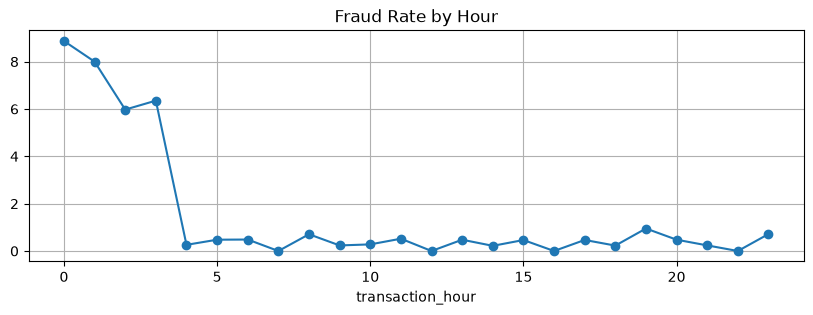

In [31]:
hour_pattern = df.groupby("transaction_hour")["is_fraud"].mean() * 100

plt.figure(figsize=(10,3))
hour_pattern.plot(marker="o")
plt.title("Fraud Rate by Hour")
plt.grid(True)
plt.show()


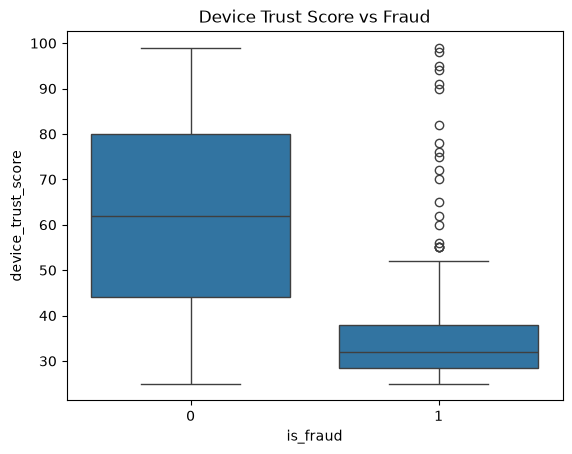

In [32]:
sns.boxplot(data=df, x="is_fraud", y="device_trust_score")
plt.title("Device Trust Score vs Fraud")
plt.show()

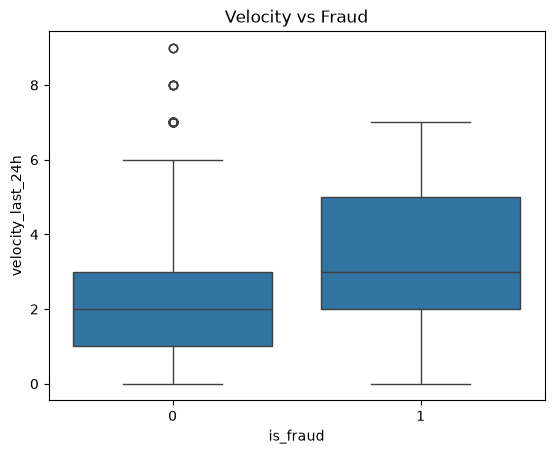

In [33]:
sns.boxplot(data=df, x="is_fraud", y="velocity_last_24h")
plt.title("Velocity vs Fraud")
plt.show()

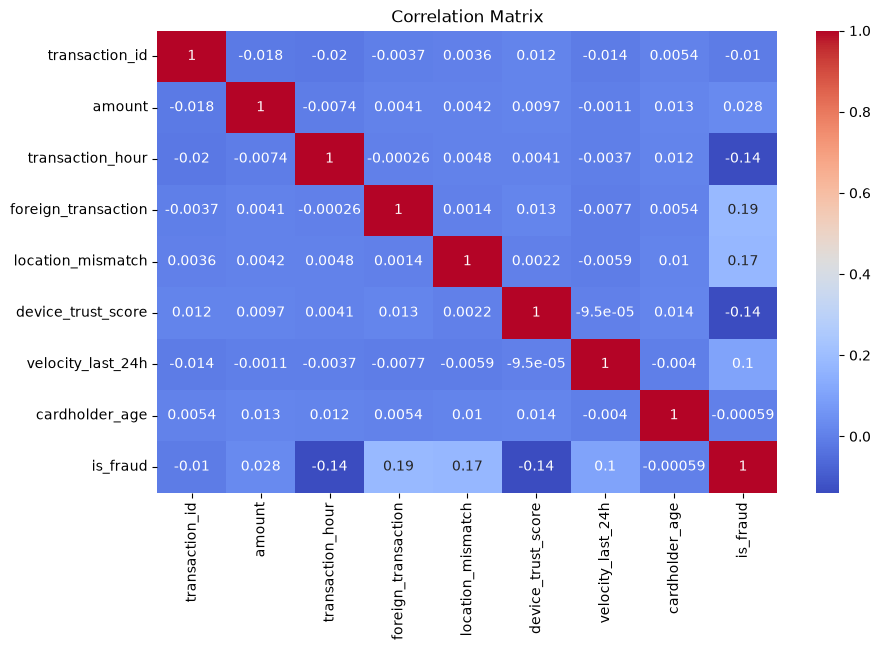

In [34]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

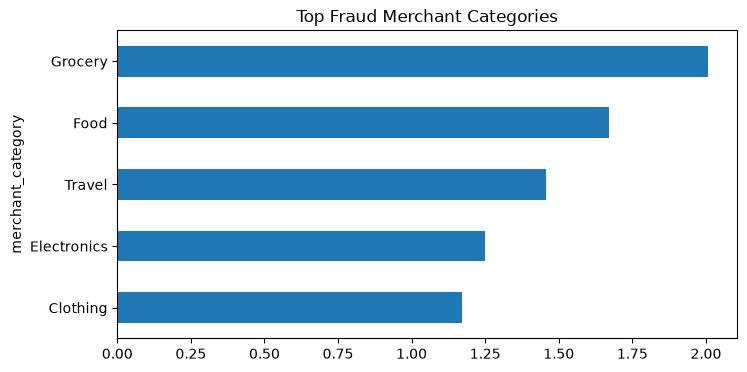

In [35]:
cat_risk = df.groupby("merchant_category")["is_fraud"].mean().sort_values(ascending=False)*100

top10 = cat_risk.head(10)

top10.sort_values().plot(kind="barh", figsize=(8,4))
plt.title("Top Fraud Merchant Categories")
plt.show()
